Connected to ni-plots (Python 3.14.2)

 # Figure reproduction from CSV data

 This script reproduces the statistical figures from the paper using the
 pre-computed CSV files in `../data/csv/`.  No mesh processing is required —
 all vertex-level measurements have already been extracted via the spatchcocking
 pipeline (notebooks 02–05) and saved as CSV.

 | Figure | Content | CSV file |
 |---|---|---|
 | Fig 1j | Cross-section area profile along RC axis | `cross_section_area.csv` |
 | Fig 1e–i | Fold changes: length, SA, volume, SA/V ratio | `compartment_lengths.csv`, `lumen_geometry.csv` |
 | Fig 3g | Gaussian curvature DV profiles per vesicle | `spatchcocked_measurements.csv` |
 | Fig 4c,f,g | Mean curvature: global comparison, DV profiles | `spatchcocked_measurements.csv` |
 | Fig 5c,f,g | Tissue thickness: global comparison, DV profiles | `spatchcocked_measurements.csv` |
 | Fig 6c,f,g | pHH3 mitotic density: global comparison, DV profiles | `spatchcocked_measurements.csv` |
 | Supp Fig 1 | Absolute geometry, fold changes, correlations | all CSVs |

 **Dependencies** (in addition to the main spatchcocking environment):
   `statannotations` — install with `pip install statannotations`

 **Run in VS Code**: open this file and use "Run Cell" (Shift+Enter) per block,
 or "Run All Cells" from the Jupyter toolbar.  Each `# %%` block is one cell.
 Outputs are saved as SVG files alongside this script.

 ## Figure 1 — Lumen geometry

 **Fig 1j** — Cross-sectional area of the lumen plotted against normalised
 rostral-caudal position.  Each point is the mean area at one z-position;
 shaded band = ±1 SD across embryos.  HH17 (blue) and HH20 (red).

 **CSV**: `cross_section_area.csv`
 Columns: `z_grid` (µm along RC axis), `area` (µm²), `stage`, `type`
 (`individual` = per-embryo datapoints used for statistics).

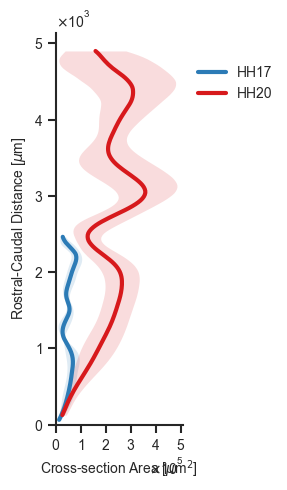

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sns.set_style("ticks")

fontsize = 10

plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'svg.fonttype': 'none',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

dpival = 100

csv_filename = '../data/csv/cross_section_area.csv'
df = pd.read_csv(csv_filename)

labels = ['HH17', 'HH20']
palette = {'HH17': '#2c7bb6', 'HH20': '#d7191c'}

fig, ax = plt.subplots(figsize=(3, 5), dpi=dpival)

for label in labels:
    stage_df = df[(df['stage'] == label) & (df['type'] == 'individual')]

    if stage_df.empty:
        continue

    stats = stage_df.groupby('z_grid')['area'].agg(['mean', 'std']).reset_index()

    stats['mean_smooth'] = stats['mean'].rolling(window=10, center=True).mean()
    stats['std_smooth'] = stats['std'].rolling(window=10, center=True).mean()
    stats = stats.dropna()

    ax.fill_betweenx(stats['z_grid'],
                     stats['mean_smooth'] - stats['std_smooth'],
                     stats['mean_smooth'] + stats['std_smooth'],
                     color=palette[label], alpha=0.15, linewidth=0)

    ax.plot(stats['mean_smooth'], stats['z_grid'],
            color=palette[label], lw=3.0, label=label)

x_step = 1e5
ax.xaxis.set_major_locator(ticker.MultipleLocator(x_step))
x_fmt = ticker.ScalarFormatter(useMathText=True)
x_fmt.set_scientific(True)
x_fmt.set_powerlimits((5, 5))
ax.xaxis.set_major_formatter(x_fmt)

y_fmt = ticker.ScalarFormatter(useMathText=True)
y_fmt.set_scientific(True)
y_fmt.set_powerlimits((3, 3))
ax.yaxis.set_major_formatter(y_fmt)

ax.set_ylabel(r'Rostral-Caudal Distance [$\mu$m]')
ax.set_xlabel(r'Cross-section Area [$\mu$m$^2$]')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

sns.despine()

ax.legend(title=" ", frameon=False, fontsize=fontsize, title_fontsize=fontsize,
          bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('__csarea-over-rclength.svg', format='svg', bbox_inches='tight')
plt.show()

 **Fig 1e–g** — Fold changes in total length, surface area, and volume
 (each embryo normalised to the HH17 group mean = 1.0).
 Welch t-test between stages; bracket = significance level.

 **Fig 1h–i** — Fold change in SA per compartment, and raw SA/V ratio per
 compartment (FB = forebrain, MB = midbrain, HB = hindbrain).
 Within-compartment (HH17 vs HH20) and inter-compartment (HH20 vs HH20)
 comparisons are shown.

 **CSVs**:
 - `compartment_lengths.csv` — columns: `stage`, `end` (total length µm),
   `mhb` (midbrain–hindbrain boundary µm), `fmb` (fore–midbrain boundary µm)
 - `lumen_geometry.csv` — columns: `Stage`, `Region`, `Area` (µm²), `Volume` (µm³)

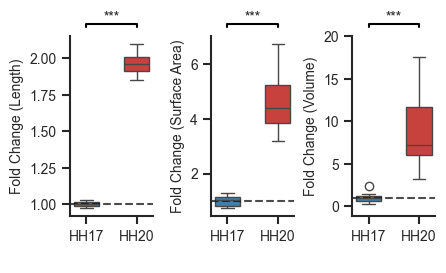

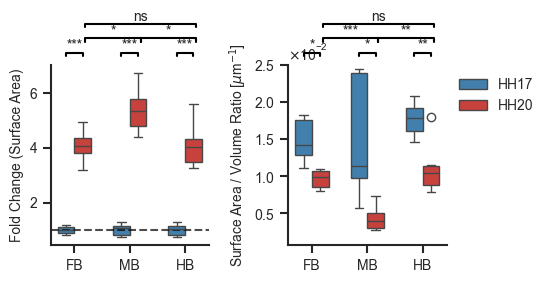

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

sns.set_style("ticks")

plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'svg.fonttype': 'none',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

dpival = 100
PALETTE = {'HH17': '#3182bd', 'HH20': '#de2d26'}
COMPARTMENTS = ['Forebrain', 'Midbrain', 'Hindbrain']
STAGES = ['HH17', 'HH20']

def set_common_style(ax, xlabel, ylabel):
    """Applies consistent L-frame (linewidths handled by rcParams)."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

def add_external_stat(ax, x1, x2, level, p_val):
    """Adds brackets OUTSIDE the axis."""
    base_y = 1.05
    step = 0.08
    y = base_y + (level * step)

    ax.plot([x1, x1, x2, x2], [y, y+0.02, y+0.02, y],
            color='black', clip_on=False, transform=ax.get_xaxis_transform())

    if p_val < 0.001: text = '***'
    elif p_val < 0.01: text = '**'
    elif p_val < 0.05: text = '*'
    else: text = 'ns'

    ax.text((x1+x2)*0.5, y+0.02, text, ha='center', va='bottom',
            transform=ax.get_xaxis_transform())

# Length Data
df_len = pd.read_csv('../data/csv/compartment_lengths.csv')
df_len['stage'] = df_len['stage'].astype(str).str.upper()
df_len['Total Length'] = df_len['end']

hh17_mean_len = df_len[df_len['stage'] == 'HH17']['Total Length'].mean()
df_len_fc = df_len.copy()
df_len_fc['Total Length FC'] = df_len['Total Length'] / hh17_mean_len

# Area & Volume Data
df_av = pd.read_csv("../data/csv/lumen_geometry.csv")
df_av['Stage'] = df_av['Stage'].astype(str).str.upper()
df_av['SA_Vol_Ratio'] = df_av['Area'] / df_av['Volume']

df_av_fc = df_av.copy()
for metric in ['Area', 'Volume']:
    for reg in COMPARTMENTS:
        hh17_mean = df_av[(df_av['Stage'] == 'HH17') & (df_av['Region'] == reg)][metric].mean()
        mask = df_av['Region'] == reg
        df_av_fc.loc[mask, metric] = df_av.loc[mask, metric] / hh17_mean


# FIGURE 1: Total Fold Changes (Length, Area, Volume)
fig1, axes1 = plt.subplots(1, 3, figsize=(4.3, 2), dpi=dpival)

fc_stage_configs = [
    (df_len_fc, 'stage', 'Total Length FC', 'Fold Change (Length)', 0),
    (df_av_fc, 'Stage', 'Area', 'Fold Change (Surface Area)', 1),
    (df_av_fc, 'Stage', 'Volume', 'Fold Change (Volume)', 2)
]

for df_plot, x_col, y_col, ylabel, i in fc_stage_configs:
    ax = axes1[i]
    sns.boxplot(data=df_plot, x=x_col, y=y_col, hue=x_col, palette=PALETTE,
                width=0.5, order=STAGES, legend=False, ax=ax)

    ax.axhline(1.0, color='black', linestyle='--', alpha=0.7)

    g1 = df_plot[df_plot[x_col] == 'HH17'][y_col]
    g2 = df_plot[df_plot[x_col] == 'HH20'][y_col]
    _, p = stats.ttest_ind(g1, g2)
    add_external_stat(ax, 0, 1, 0, p)

    set_common_style(ax, ' ', ylabel)

axes1[2].set_ylim(top=20)

fig1.subplots_adjust(top=0.95, bottom=0.05, left=0.10, right=0.95, wspace=0.7)
fig1.savefig("__fig1_total_fold_changes.svg", format='svg', bbox_inches='tight')
plt.show()


# FIGURE 2: Fold Change SA & SA/Vol Ratio by Compartment
fig2, axes2 = plt.subplots(1, 2, figsize=(5.5, 2), dpi=dpival)

ax_fc_area = axes2[0]
sns.boxplot(data=df_av_fc, x='Region', y='Area', hue='Stage',
            order=COMPARTMENTS, palette=PALETTE, width=0.6, ax=ax_fc_area)
ax_fc_area.axhline(1.0, color='black', linestyle='--', alpha=0.7)
set_common_style(ax_fc_area, ' ', 'Fold Change (Surface Area)')
ax_fc_area.legend_.remove()

ax_ratio = axes2[1]
sns.boxplot(data=df_av, x='Region', y='SA_Vol_Ratio', hue='Stage',
            order=COMPARTMENTS, palette=PALETTE, width=0.6, ax=ax_ratio)
set_common_style(ax_ratio, ' ', r'Surface Area / Volume Ratio [$\mu$m$^{-1}$]')
ax_ratio.set_ylim(top=2.5e-2)

fmt = ticker.ScalarFormatter(useMathText=True)
fmt.set_scientific(True)
fmt.set_powerlimits((-2, -2))
ax_ratio.yaxis.set_major_formatter(fmt)

ax_ratio.legend(frameon=False, loc='upper left', bbox_to_anchor=(1, 1))

inter_comps = [(0, 1, 1), (1, 2, 1), (0, 2, 2)]

for ax, df_plot, metric in [(ax_fc_area, df_av_fc, 'Area'), (ax_ratio, df_av, 'SA_Vol_Ratio')]:
    for i, comp in enumerate(COMPARTMENTS):
        d1 = df_plot[(df_plot['Region'] == comp) & (df_plot['Stage'] == 'HH17')][metric]
        d2 = df_plot[(df_plot['Region'] == comp) & (df_plot['Stage'] == 'HH20')][metric]
        _, p = stats.ttest_ind(d1, d2)
        add_external_stat(ax, i - 0.15, i + 0.15, 0, p)

    for (idx1, idx2, level) in inter_comps:
        c1, c2 = COMPARTMENTS[idx1], COMPARTMENTS[idx2]
        d1 = df_plot[(df_plot['Region'] == c1) & (df_plot['Stage'] == 'HH20')][metric]
        d2 = df_plot[(df_plot['Region'] == c2) & (df_plot['Stage'] == 'HH20')][metric]
        _, p = stats.ttest_ind(d1, d2)
        add_external_stat(ax, idx1 + 0.2, idx2 + 0.2, level, p)

for ax in axes2:
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['FB', 'MB', 'HB'])

fig2.subplots_adjust(top=0.95, bottom=0.05, left=0.08, right=0.80, wspace=0.5)
fig2.savefig("__fig2_compartment_sa_and_ratio.svg", format='svg', bbox_inches='tight')
plt.show()

 ## Figure 3 — Gaussian curvature DV profiles

 **Fig 3g** — Dorso-ventral profiles of Gaussian curvature *K* [µm⁻²] for each
 brain vesicle (forebrain, midbrain, hindbrain).  Line = mean across embryos;
 shaded band = ±1 SD.  Angle θ = 0° is dorsal, ±180° is ventral.

 Compartments are defined by normalised rostral-caudal position (`norm_height`):
 - HH17: FB > 0.80, MB 0.60–0.80, HB < 0.60
 - HH20: FB > 0.75, MB 0.55–0.75, HB < 0.55

 **CSV**: `spatchcocked_measurements.csv`
 Each row is one mesh vertex from one embryo, with columns:
 `stage`, `timepoint` (embryo ID), `norm_height`, `angle_degrees`,
 `Gauss_Curvature`, `Mean_Curvature`, `K1`, `K2`, `thickness`, `phh3`

Plot saved: __compartment_plot_Gauss_Curvature.svg


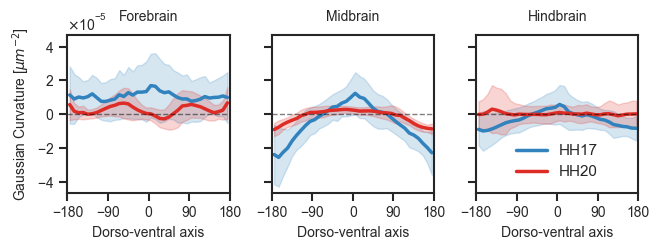

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sns.set_theme(style="ticks")

plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'svg.fonttype': 'none',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

TARGET_METRIC = 'Gauss_Curvature'

property_map = {
    'Gauss_Curvature': r'Gaussian Curvature [$\mu m^{-2}$]',
    'Mean_Curvature':  r'Mean Curvature [$\mu m^{-1}$]',
    'K1':               r'K1 [$\mu m^{-1}$]',
    'K2':               r'K2 [$\mu m^{-1}$]',
    'thickness':        r'Thickness [$\mu m$]',
    'phh3':             'Local pH3+ cell count'
}

master_csv = "../data/csv/spatchcocked_measurements.csv"
df = pd.read_csv(master_csv)

df['stage'] = df['stage'].astype(str).str.upper()

df['Compartment'] = None

mask_hh17 = df['stage'] == 'HH17'
df.loc[mask_hh17 & (df['norm_height'] < 0.6), 'Compartment'] = 'Hindbrain'
df.loc[mask_hh17 & (df['norm_height'] >= 0.6) & (df['norm_height'] <= 0.8), 'Compartment'] = 'Midbrain'
df.loc[mask_hh17 & (df['norm_height'] > 0.8), 'Compartment'] = 'Forebrain'

mask_hh20 = df['stage'] == 'HH20'
df.loc[mask_hh20 & (df['norm_height'] < 0.55), 'Compartment'] = 'Hindbrain'
df.loc[mask_hh20 & (df['norm_height'] >= 0.55) & (df['norm_height'] <= 0.75), 'Compartment'] = 'Midbrain'
df.loc[mask_hh20 & (df['norm_height'] > 0.75), 'Compartment'] = 'Forebrain'

df['angle_bin'] = pd.cut(df['angle_degrees'], bins=np.arange(-180, 190, 10))
df['angle_bin_center'] = df['angle_bin'].apply(lambda x: x.mid).astype(float)

stage_palette = {"HH17": "#3182bd", "HH20": "#de2d26"}
compartments = ['Forebrain', 'Midbrain', 'Hindbrain']
ylabel = property_map[TARGET_METRIC]

fig, axes = plt.subplots(1, 3, figsize=(6.7, 2.6), sharey=True, dpi=100)

for i, comp in enumerate(compartments):
    comp_data = df[df['Compartment'] == comp]
    ax = axes[i]

    sns.lineplot(
        data=comp_data,
        x='angle_bin_center',
        y=TARGET_METRIC,
        hue='stage',
        palette=stage_palette,
        linewidth=2.5,
        errorbar='sd',
        ax=ax
    )

    ax.set_title(comp, pad=10)
    ax.set_xlabel('Dorso-ventral axis')
    ax.set_xticks([-180, -90, 0, 90, 180])
    ax.set_xlim(-180, 180)

    if i == 0:
        ax.set_ylabel(ylabel)
    else:
        ax.set_ylabel('')

    if i == 2:
        ax.legend(title=' ', loc='best', frameon=False)
    else:
        ax.get_legend().remove()

    if 'Curvature' in TARGET_METRIC or TARGET_METRIC in ['K1', 'K2']:
        ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

    for spine in ax.spines.values():
        spine.set_visible(True)

if 'Curvature' in TARGET_METRIC or TARGET_METRIC in ['K1', 'K2']:
    ymin, ymax = axes[0].get_ylim()
    abs_max = max(abs(ymin), abs(ymax))
    axes[0].set_ylim(bottom=-abs_max, top=abs_max)

if TARGET_METRIC in ['thickness', 'phh3']:
    axes[0].set_ylim(bottom=0)

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 3))
axes[0].yaxis.set_major_formatter(formatter)

plt.tight_layout()
save_path = f"__compartment_plot_{TARGET_METRIC}.svg"
plt.savefig(save_path, format='svg', bbox_inches='tight')
print(f"Plot saved: {save_path}")
plt.show()

 ## Figure 4 — Mean curvature

 **Fig 4c** — Global mean curvature *H* [µm⁻¹] comparison between HH17 and
 HH20.  Each data point is the per-embryo mean; Welch t-test annotated with
 stars (statannotations library).

 **Fig 4f** — DV profiles of *H* per vesicle (same layout as Fig 3g).

 **Fig 4g** — Overall DV profile of *H* pooling all three vesicles.

Plot saved: __compartment_plot_Mean_Curvature.svg


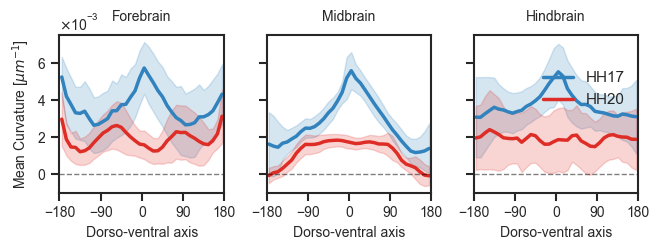

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sns.set_theme(style="ticks")

plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'svg.fonttype': 'none',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

TARGET_METRIC = 'Mean_Curvature'

property_map = {
    'Gauss_Curvature': r'Gaussian Curvature [$\mu m^{-2}$]',
    'Mean_Curvature':  r'Mean Curvature [$\mu m^{-1}$]',
    'K1':               r'K1 [$\mu m^{-1}$]',
    'K2':               r'K2 [$\mu m^{-1}$]',
    'thickness':        r'Thickness [$\mu m$]',
    'phh3':             'Local pH3+ cell count'
}

master_csv = "../data/csv/spatchcocked_measurements.csv"
df = pd.read_csv(master_csv)

df['stage'] = df['stage'].astype(str).str.upper()

df['Compartment'] = None

mask_hh17 = df['stage'] == 'HH17'
df.loc[mask_hh17 & (df['norm_height'] < 0.6), 'Compartment'] = 'Hindbrain'
df.loc[mask_hh17 & (df['norm_height'] >= 0.6) & (df['norm_height'] <= 0.8), 'Compartment'] = 'Midbrain'
df.loc[mask_hh17 & (df['norm_height'] > 0.8), 'Compartment'] = 'Forebrain'

mask_hh20 = df['stage'] == 'HH20'
df.loc[mask_hh20 & (df['norm_height'] < 0.55), 'Compartment'] = 'Hindbrain'
df.loc[mask_hh20 & (df['norm_height'] >= 0.55) & (df['norm_height'] <= 0.75), 'Compartment'] = 'Midbrain'
df.loc[mask_hh20 & (df['norm_height'] > 0.75), 'Compartment'] = 'Forebrain'

df['angle_bin'] = pd.cut(df['angle_degrees'], bins=np.arange(-180, 190, 10))
df['angle_bin_center'] = df['angle_bin'].apply(lambda x: x.mid).astype(float)

stage_palette = {"HH17": "#3182bd", "HH20": "#de2d26"}
compartments = ['Forebrain', 'Midbrain', 'Hindbrain']
ylabel = property_map[TARGET_METRIC]

fig, axes = plt.subplots(1, 3, figsize=(6.7, 2.6), sharey=True, dpi=100)

for i, comp in enumerate(compartments):
    comp_data = df[df['Compartment'] == comp]
    ax = axes[i]

    sns.lineplot(
        data=comp_data,
        x='angle_bin_center',
        y=TARGET_METRIC,
        hue='stage',
        palette=stage_palette,
        linewidth=2.5,
        errorbar='sd',
        ax=ax
    )

    ax.set_title(comp, pad=10)
    ax.set_xlabel('Dorso-ventral axis')
    ax.set_xticks([-180, -90, 0, 90, 180])
    ax.set_xlim(-180, 180)

    if i == 0:
        ax.set_ylabel(ylabel)
    else:
        ax.set_ylabel('')

    if i == 2:
        ax.legend(title=' ', loc='best', frameon=False)
    else:
        ax.get_legend().remove()

    if 'Curvature' in TARGET_METRIC or TARGET_METRIC in ['K1', 'K2']:
        ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

    for spine in ax.spines.values():
        spine.set_visible(True)

if 'Curvature' in TARGET_METRIC or TARGET_METRIC in ['K1', 'K2']:
    ymin, ymax = axes[0].get_ylim()
    abs_max = max(abs(ymin), abs(ymax))
    axes[0].set_ylim(top=abs_max)

if TARGET_METRIC in ['thickness', 'phh3']:
    axes[0].set_ylim(bottom=0)

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 3))
axes[0].yaxis.set_major_formatter(formatter)

plt.tight_layout()
save_path = f"__compartment_plot_{TARGET_METRIC}.svg"
plt.savefig(save_path, format='svg', bbox_inches='tight')
print(f"Plot saved: {save_path}")
plt.show()

Overall plot saved: __overall_dv_plot_Mean_Curvature.svg


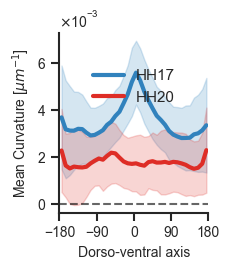

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sns.set_theme(style="ticks")

plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'svg.fonttype': 'none',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

TARGET_METRIC = 'Mean_Curvature'

property_map = {
    'Gauss_Curvature': r'Gaussian Curvature [$\mu m^{-2}$]',
    'Mean_Curvature':  r'Mean Curvature [$\mu m^{-1}$]',
    'K1':               r'K1 [$\mu m^{-1}$]',
    'K2':               r'K2 [$\mu m^{-1}$]',
    'thickness':        r'Thickness [$\mu m$]',
    'phh3':             'Local pH3+ cell count'
}

master_csv = "../data/csv/spatchcocked_measurements.csv"
df = pd.read_csv(master_csv)

df['stage'] = df['stage'].astype(str).str.upper()

df['angle_bin'] = pd.cut(df['angle_degrees'], bins=np.arange(-180, 190, 10))
df['angle_bin_center'] = df['angle_bin'].apply(lambda x: x.mid).astype(float)

stage_palette = {"HH17": "#3182bd", "HH20": "#de2d26"}
ylabel = property_map.get(TARGET_METRIC, TARGET_METRIC)

fig, ax = plt.subplots(figsize=(2.4, 2.8), dpi=100)

sns.lineplot(
    data=df,
    x='angle_bin_center',
    y=TARGET_METRIC,
    hue='stage',
    palette=stage_palette,
    linewidth=3,
    errorbar='sd',
    ax=ax
)

ax.set_xlabel('Dorso-ventral axis')
ax.set_ylabel(ylabel)

ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_xlim(-180, 180)

if 'Curvature' in TARGET_METRIC or TARGET_METRIC in ['K1', 'K2']:
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(title=' ', loc='best', frameon=False)

if 'Curvature' in TARGET_METRIC or TARGET_METRIC in ['K1', 'K2']:
    ymin, ymax = ax.get_ylim()
    abs_max = max(abs(ymin), abs(ymax))
    ax.set_ylim(top=abs_max)

if TARGET_METRIC in ['thickness', 'phh3']:
    ax.set_ylim(bottom=0)

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 3))
ax.yaxis.set_major_formatter(formatter)

plt.tight_layout()

save_path = f"__overall_dv_plot_{TARGET_METRIC}.svg"
plt.savefig(save_path, format='svg', bbox_inches='tight')
print(f"Overall plot saved: {save_path}")
plt.show()

<ipython-input-6-04482e770fe8>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=median_df, x='stage', y=TARGET_METRIC, palette=palette, order=order, width=0.5, ax=ax, fliersize=0)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

HH17 vs. HH20: t-test independent samples, P_val:3.407e-04 t=1.137e+01


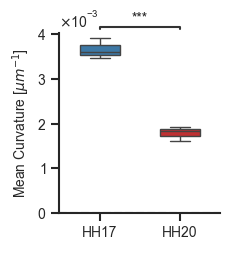

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from statannotations.Annotator import Annotator

TARGET_METRIC = 'Mean_Curvature'
Y_LABEL = r'Mean Curvature [$\mu m^{-1}$]'

FONT_SIZE = 10

plt.rcParams.update({
    'svg.fonttype': 'none',
    'font.size': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'xtick.labelsize': FONT_SIZE,
    'ytick.labelsize': FONT_SIZE,
    'legend.fontsize': FONT_SIZE,
    'axes.titlesize': FONT_SIZE,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

palette = {'HH17': '#2c7bb6', 'HH20': '#d7191c'}

df = pd.read_csv("../data/csv/spatchcocked_measurements.csv")
df['stage'] = df['stage'].astype(str).str.upper()
median_df = df.groupby(['timepoint', 'stage'])[TARGET_METRIC].mean().reset_index()

fig, ax = plt.subplots(figsize=(2.4, 2.8), dpi=100)
order = ['HH17', 'HH20']

sns.boxplot(data=median_df, x='stage', y=TARGET_METRIC, palette=palette, order=order, width=0.5, ax=ax, fliersize=0)

annotator = Annotator(ax, [("HH17", "HH20")], data=median_df, x='stage', y=TARGET_METRIC, order=order)
annotator.configure(test='t-test_ind', text_format='star', loc='outside')
annotator.apply_and_annotate()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.set_ylabel(Y_LABEL)
ax.set_xlabel(" ")

ymin, ymax = ax.get_ylim()
abs_max = max(abs(ymin), abs(ymax))
ax.set_ylim(bottom=0, top=abs_max)

ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, zorder=0)

fmt = ticker.ScalarFormatter(useMathText=True)
fmt.set_scientific(True)
fmt.set_powerlimits((-3, 3))
ax.yaxis.set_major_formatter(fmt)
ax.yaxis.get_offset_text().set_fontsize(FONT_SIZE)

plt.tight_layout()
plt.savefig(f"__global_stat_{TARGET_METRIC}.svg", format='svg')
plt.show()

 ## Figure 5 — Tissue thickness

 **Fig 5c** — Global tissue thickness [µm] comparison HH17 vs HH20 (per-embryo
 means, boxplot + Welch t-test).

 **Fig 5f** — DV profiles of thickness per vesicle (same format as Fig 3g).

 **Fig 5g** — Compartment-wise boxplots of thickness, with within-compartment
 (HH17 vs HH20) and inter-compartment (HH20 only) significance brackets.

 Thickness is measured as the Euclidean distance from each lumen surface vertex
 to the nearest point on the basal (outer) surface mesh (notebook 03).

Plot saved: __compartment_plot_thickness.svg


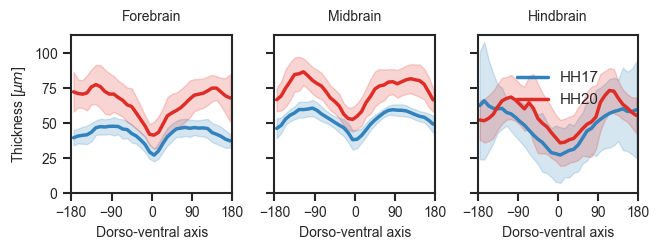

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sns.set_theme(style="ticks")

plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'svg.fonttype': 'none',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

TARGET_METRIC = 'thickness'

property_map = {
    'Gauss_Curvature': r'Gaussian Curvature [$\mu m^{-2}$]',
    'Mean_Curvature':  r'Mean Curvature [$\mu m^{-1}$]',
    'K1':               r'K1 [$\mu m^{-1}$]',
    'K2':               r'K2 [$\mu m^{-1}$]',
    'thickness':        r'Thickness [$\mu m$]',
    'phh3':             'Local pH3+ cell count'
}

master_csv = "../data/csv/spatchcocked_measurements.csv"
df = pd.read_csv(master_csv)

df['stage'] = df['stage'].astype(str).str.upper()

df['Compartment'] = None

mask_hh17 = df['stage'] == 'HH17'
df.loc[mask_hh17 & (df['norm_height'] < 0.6), 'Compartment'] = 'Hindbrain'
df.loc[mask_hh17 & (df['norm_height'] >= 0.6) & (df['norm_height'] <= 0.8), 'Compartment'] = 'Midbrain'
df.loc[mask_hh17 & (df['norm_height'] > 0.8), 'Compartment'] = 'Forebrain'

mask_hh20 = df['stage'] == 'HH20'
df.loc[mask_hh20 & (df['norm_height'] < 0.55), 'Compartment'] = 'Hindbrain'
df.loc[mask_hh20 & (df['norm_height'] >= 0.55) & (df['norm_height'] <= 0.75), 'Compartment'] = 'Midbrain'
df.loc[mask_hh20 & (df['norm_height'] > 0.75), 'Compartment'] = 'Forebrain'

df['angle_bin'] = pd.cut(df['angle_degrees'], bins=np.arange(-180, 190, 10))
df['angle_bin_center'] = df['angle_bin'].apply(lambda x: x.mid).astype(float)

stage_palette = {"HH17": "#3182bd", "HH20": "#de2d26"}
compartments = ['Forebrain', 'Midbrain', 'Hindbrain']
ylabel = property_map[TARGET_METRIC]

fig, axes = plt.subplots(1, 3, figsize=(6.7, 2.6), sharey=True, dpi=100)

for i, comp in enumerate(compartments):
    comp_data = df[df['Compartment'] == comp]
    ax = axes[i]

    sns.lineplot(
        data=comp_data,
        x='angle_bin_center',
        y=TARGET_METRIC,
        hue='stage',
        palette=stage_palette,
        linewidth=2.5,
        errorbar='sd',
        ax=ax
    )

    ax.set_title(comp, pad=10)
    ax.set_xlabel('Dorso-ventral axis')
    ax.set_xticks([-180, -90, 0, 90, 180])
    ax.set_xlim(-180, 180)

    if i == 0:
        ax.set_ylabel(ylabel)
    else:
        ax.set_ylabel('')

    if i == 2:
        ax.legend(title=' ', loc='best', frameon=False)
    else:
        ax.get_legend().remove()

    if 'Curvature' in TARGET_METRIC or TARGET_METRIC in ['K1', 'K2']:
        ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

    for spine in ax.spines.values():
        spine.set_visible(True)

if 'Curvature' in TARGET_METRIC or TARGET_METRIC in ['K1', 'K2']:
    ymin, ymax = axes[0].get_ylim()
    abs_max = max(abs(ymin), abs(ymax))
    axes[0].set_ylim(top=abs_max)

if TARGET_METRIC in ['thickness', 'phh3']:
    axes[0].set_ylim(bottom=0)

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 3))
axes[0].yaxis.set_major_formatter(formatter)

plt.tight_layout()
save_path = f"__compartment_plot_{TARGET_METRIC}.svg"
plt.savefig(save_path, format='svg', bbox_inches='tight')
print(f"Plot saved: {save_path}")
plt.show()

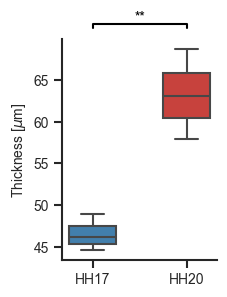

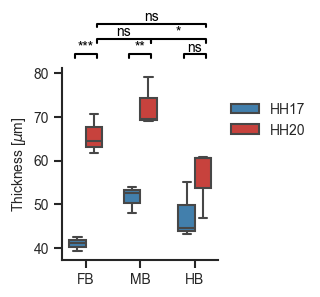

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

dpival = 100
FONT_SIZE = 10

plt.rcParams.update({
    'svg.fonttype': 'none',
    'font.size': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'xtick.labelsize': FONT_SIZE,
    'ytick.labelsize': FONT_SIZE,
    'legend.fontsize': FONT_SIZE,
    'axes.titlesize': FONT_SIZE,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

PALETTE = {'HH17': '#3182bd', 'HH20': '#de2d26'}
COMPARTMENTS = ['Forebrain', 'Midbrain', 'Hindbrain']
STAGES = ['HH17', 'HH20']

def set_common_style(ax, ylabel):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for side in ['left', 'bottom']:
        ax.spines[side].set_linewidth(1.5)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

def add_external_stat(ax, x1, x2, level, p_val):
    base_y = 1.05
    step = 0.08
    y = base_y + (level * step)
    ax.plot([x1, x1, x2, x2], [y, y+0.02, y+0.02, y],
            lw=1.5, color='black', clip_on=False,
            transform=ax.get_xaxis_transform())
    if p_val < 0.001: text = '***'
    elif p_val < 0.01: text = '**'
    elif p_val < 0.05: text = '*'
    else: text = 'ns'
    ax.text((x1+x2)*0.5, y+0.02, text, ha='center', va='bottom',
            color='black', transform=ax.get_xaxis_transform())

master_csv = "../data/csv/spatchcocked_measurements.csv"
df_raw = pd.read_csv(master_csv)
df_raw['stage'] = df_raw['stage'].astype(str).str.upper()

df_raw['Compartment'] = None
for stage, bounds in {'HH17': (0.6, 0.8), 'HH20': (0.55, 0.75)}.items():
    mask = df_raw['stage'] == stage
    df_raw.loc[mask & (df_raw['norm_height'] < bounds[0]), 'Compartment'] = 'Hindbrain'
    df_raw.loc[mask & (df_raw['norm_height'] >= bounds[0]) & (df_raw['norm_height'] <= bounds[1]), 'Compartment'] = 'Midbrain'
    df_raw.loc[mask & (df_raw['norm_height'] > bounds[1]), 'Compartment'] = 'Forebrain'

df_total = df_raw.groupby(['timepoint', 'stage'])['thickness'].mean().reset_index()
df_comp = df_raw.groupby(['timepoint', 'stage', 'Compartment'])['thickness'].mean().reset_index()

def plot_total_thickness(data, y_col, ylabel, filename):
    plt.figure(figsize=(2, 3.2), dpi=dpival)
    ax = sns.boxplot(data=data, x='stage', y=y_col, hue='stage', palette=PALETTE,
                     width=0.5, linewidth=1.5, order=STAGES, legend=False)
    g1 = data[data['stage'] == 'HH17'][y_col]
    g2 = data[data['stage'] == 'HH20'][y_col]
    _, p = stats.ttest_ind(g1, g2)
    add_external_stat(ax, 0, 1, 0, p)
    set_common_style(ax, ylabel)
    plt.subplots_adjust(top=0.8)
    plt.savefig(f"{filename}.svg", format='svg', bbox_inches='tight')

def plot_compartment_thickness(data, y_col, ylabel, filename):
    plt.figure(figsize=(2.5, 3.0), dpi=dpival)
    ax = sns.boxplot(data=data, x='Compartment', y=y_col, hue='stage',
                     order=COMPARTMENTS, palette=PALETTE, width=0.6, linewidth=1.5)
    for i, comp in enumerate(COMPARTMENTS):
        d1 = data[(data['Compartment'] == comp) & (data['stage'] == 'HH17')][y_col]
        d2 = data[(data['Compartment'] == comp) & (data['stage'] == 'HH20')][y_col]
        _, p = stats.ttest_ind(d1, d2)
        add_external_stat(ax, i - 0.2, i + 0.2, 0, p)
    inter_comps = [(0, 1, 1), (1, 2, 1), (0, 2, 2)]
    for (idx1, idx2, level) in inter_comps:
        comp1, comp2 = COMPARTMENTS[idx1], COMPARTMENTS[idx2]
        d1 = data[(data['Compartment'] == comp1) & (data['stage'] == 'HH20')][y_col]
        d2 = data[(data['Compartment'] == comp2) & (data['stage'] == 'HH20')][y_col]
        _, p = stats.ttest_ind(d1, d2)
        add_external_stat(ax, idx1 + 0.2, idx2 + 0.2, level, p)
    set_common_style(ax, ylabel)
    plt.legend(frameon=False, loc='best', bbox_to_anchor=(1, 1), title=' ')
    ax.set_xticks(range(len(COMPARTMENTS)))
    ax.set_xticklabels(['FB', 'MB', 'HB'])
    plt.subplots_adjust(top=0.75, right=0.75)
    plt.savefig(f"{filename}.svg", format='svg', bbox_inches='tight')

plot_total_thickness(df_total, 'thickness', r'Thickness [$\mu$m]', 'thickness_total_raw')
plot_compartment_thickness(df_comp, 'thickness', r'Thickness [$\mu$m]', 'thickness_comp_raw')
plt.show()

 ## Figure 6 — Mitotic cell density (pHH3)

 **Fig 6c** — Global pHH3+ cell density comparison HH17 vs HH20.

 **Fig 6f** — DV profiles of pHH3+ density per vesicle.

 **Fig 6g** — Compartment-wise boxplots of pHH3+ density.

 pHH3 (phospho-Histone H3) marks cells in mitosis.  The local density at
 each lumen surface vertex is the number of pHH3+ spots (detected in Imaris)
 within a sphere of radius R = 100 µm, interpolated onto the mesh via inverse
 distance weighting (notebook 04).

Plot saved: __compartment_plot_phh3.svg


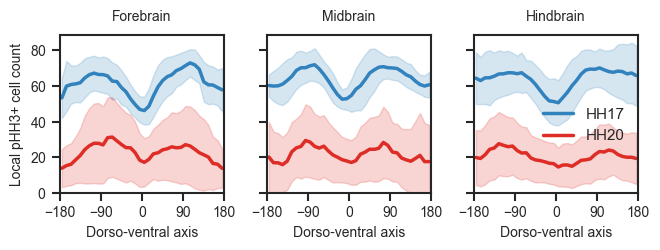

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sns.set_theme(style="ticks")

plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'svg.fonttype': 'none',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

TARGET_METRIC = 'phh3'

property_map = {
    'Gauss_Curvature': r'Gaussian Curvature [$\mu m^{-2}$]',
    'Mean_Curvature':  r'Mean Curvature [$\mu m^{-1}$]',
    'K1':               r'K1 [$\mu m^{-1}$]',
    'K2':               r'K2 [$\mu m^{-1}$]',
    'thickness':        r'Thickness [$\mu m$]',
    'phh3':             'Local pHH3+ cell count'
}

master_csv = "../data/csv/spatchcocked_measurements.csv"
df = pd.read_csv(master_csv)

df['stage'] = df['stage'].astype(str).str.upper()

df['Compartment'] = None

mask_hh17 = df['stage'] == 'HH17'
df.loc[mask_hh17 & (df['norm_height'] < 0.6), 'Compartment'] = 'Hindbrain'
df.loc[mask_hh17 & (df['norm_height'] >= 0.6) & (df['norm_height'] <= 0.8), 'Compartment'] = 'Midbrain'
df.loc[mask_hh17 & (df['norm_height'] > 0.8), 'Compartment'] = 'Forebrain'

mask_hh20 = df['stage'] == 'HH20'
df.loc[mask_hh20 & (df['norm_height'] < 0.55), 'Compartment'] = 'Hindbrain'
df.loc[mask_hh20 & (df['norm_height'] >= 0.55) & (df['norm_height'] <= 0.75), 'Compartment'] = 'Midbrain'
df.loc[mask_hh20 & (df['norm_height'] > 0.75), 'Compartment'] = 'Forebrain'

df['angle_bin'] = pd.cut(df['angle_degrees'], bins=np.arange(-180, 190, 10))
df['angle_bin_center'] = df['angle_bin'].apply(lambda x: x.mid).astype(float)

stage_palette = {"HH17": "#3182bd", "HH20": "#de2d26"}
compartments = ['Forebrain', 'Midbrain', 'Hindbrain']
ylabel = property_map[TARGET_METRIC]

fig, axes = plt.subplots(1, 3, figsize=(6.7, 2.6), sharey=True, dpi=100)

for i, comp in enumerate(compartments):
    comp_data = df[df['Compartment'] == comp]
    ax = axes[i]

    sns.lineplot(
        data=comp_data,
        x='angle_bin_center',
        y=TARGET_METRIC,
        hue='stage',
        palette=stage_palette,
        linewidth=2.5,
        errorbar='sd',
        ax=ax
    )

    ax.set_title(comp, pad=10)
    ax.set_xlabel('Dorso-ventral axis')
    ax.set_xticks([-180, -90, 0, 90, 180])
    ax.set_xlim(-180, 180)

    if i == 0:
        ax.set_ylabel(ylabel)
    else:
        ax.set_ylabel('')

    if i == 2:
        ax.legend(title=' ', loc='best', frameon=False)
    else:
        ax.get_legend().remove()

    if 'Curvature' in TARGET_METRIC or TARGET_METRIC in ['K1', 'K2']:
        ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

    for spine in ax.spines.values():
        spine.set_visible(True)

if 'Curvature' in TARGET_METRIC or TARGET_METRIC in ['K1', 'K2']:
    ymin, ymax = axes[0].get_ylim()
    abs_max = max(abs(ymin), abs(ymax))
    axes[0].set_ylim(top=abs_max)

if TARGET_METRIC in ['thickness', 'phh3']:
    axes[0].set_ylim(bottom=0)

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 3))
axes[0].yaxis.set_major_formatter(formatter)

plt.tight_layout()
save_path = f"__compartment_plot_{TARGET_METRIC}.svg"
plt.savefig(save_path, format='svg', bbox_inches='tight')
print(f"Plot saved: {save_path}")
plt.show()

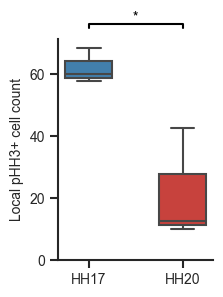

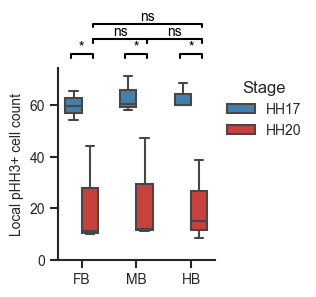

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

dpival = 100
FONT_SIZE = 10

plt.rcParams.update({
    'svg.fonttype': 'none',
    'font.size': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'xtick.labelsize': FONT_SIZE,
    'ytick.labelsize': FONT_SIZE,
    'legend.fontsize': FONT_SIZE,
    'axes.titlesize': FONT_SIZE,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

PALETTE = {'HH17': '#3182bd', 'HH20': '#de2d26'}
COMPARTMENTS = ['Forebrain', 'Midbrain', 'Hindbrain']
STAGES = ['HH17', 'HH20']
TARGET_METRIC = 'phh3'

def set_common_style(ax, ylabel):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for side in ['left', 'bottom']:
        ax.spines[side].set_linewidth(1.5)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

def add_external_stat(ax, x1, x2, level, p_val):
    base_y = 1.05
    step = 0.08
    y = base_y + (level * step)
    ax.plot([x1, x1, x2, x2], [y, y+0.02, y+0.02, y],
            lw=1.5, color='black', clip_on=False,
            transform=ax.get_xaxis_transform())
    if p_val < 0.001: text = '***'
    elif p_val < 0.01: text = '**'
    elif p_val < 0.05: text = '*'
    else: text = 'ns'
    ax.text((x1+x2)*0.5, y+0.02, text, ha='center', va='bottom',
            color='black', transform=ax.get_xaxis_transform())

master_csv = "../data/csv/spatchcocked_measurements.csv"
df_raw = pd.read_csv(master_csv)
df_raw['stage'] = df_raw['stage'].astype(str).str.upper()

df_raw['Compartment'] = None
for stage, bounds in {'HH17': (0.6, 0.8), 'HH20': (0.55, 0.75)}.items():
    mask = df_raw['stage'] == stage
    df_raw.loc[mask & (df_raw['norm_height'] < bounds[0]), 'Compartment'] = 'Hindbrain'
    df_raw.loc[mask & (df_raw['norm_height'] >= bounds[0]) & (df_raw['norm_height'] <= bounds[1]), 'Compartment'] = 'Midbrain'
    df_raw.loc[mask & (df_raw['norm_height'] > bounds[1]), 'Compartment'] = 'Forebrain'

df_total = df_raw.groupby(['timepoint', 'stage'])[TARGET_METRIC].mean().reset_index()
df_comp = df_raw.groupby(['timepoint', 'stage', 'Compartment'])[TARGET_METRIC].mean().reset_index()

def plot_total_phh3(data, y_col, ylabel, filename, L=False):
    plt.figure(figsize=(2, 3.2), dpi=dpival)
    ax = sns.boxplot(data=data, x='stage', y=y_col, hue='stage', palette=PALETTE,
                     width=0.5, linewidth=1.5, order=STAGES, legend=False)
    if L:
        ax.set_ylim(bottom=0)
    if 'Fold' in ylabel:
        plt.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    g1 = data[data['stage'] == 'HH17'][y_col]
    g2 = data[data['stage'] == 'HH20'][y_col]
    _, p = stats.ttest_ind(g1, g2)
    add_external_stat(ax, 0, 1, 0, p)
    set_common_style(ax, ylabel)
    plt.subplots_adjust(top=0.8)
    plt.savefig(f"{filename}.svg", format='svg', bbox_inches='tight')

def plot_compartments_phh3(data, y_col, ylabel, filename, L=False):
    plt.figure(figsize=(2.5, 3), dpi=dpival)
    ax = sns.boxplot(data=data, x='Compartment', y=y_col, hue='stage',
                     order=COMPARTMENTS, palette=PALETTE, width=0.6, linewidth=1.5)
    if L:
        ax.set_ylim(bottom=0)
    if 'Fold' in ylabel:
        plt.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    for i, comp in enumerate(COMPARTMENTS):
        d1 = data[(data['Compartment'] == comp) & (data['stage'] == 'HH17')][y_col]
        d2 = data[(data['Compartment'] == comp) & (data['stage'] == 'HH20')][y_col]
        _, p = stats.ttest_ind(d1, d2)
        add_external_stat(ax, i - 0.2, i + 0.2, 0, p)
    inter_comps = [(0, 1, 1), (1, 2, 1), (0, 2, 2)]
    for (idx1, idx2, level) in inter_comps:
        comp1, comp2 = COMPARTMENTS[idx1], COMPARTMENTS[idx2]
        d1 = data[(data['Compartment'] == comp1) & (data['stage'] == 'HH20')][y_col]
        d2 = data[(data['Compartment'] == comp2) & (data['stage'] == 'HH20')][y_col]
        _, p = stats.ttest_ind(d1, d2)
        add_external_stat(ax, idx1 + 0.2, idx2 + 0.2, level, p)
    set_common_style(ax, ylabel)
    plt.legend(frameon=False, loc='upper left', bbox_to_anchor=(1, 1), title='Stage')
    ax.set_xticks(range(len(COMPARTMENTS)))
    ax.set_xticklabels(['FB', 'MB', 'HB'])
    plt.subplots_adjust(top=0.75, right=0.75)
    plt.savefig(f"{filename}.svg", format='svg', bbox_inches='tight')

plot_total_phh3(df_total, TARGET_METRIC, 'Local pHH3+ cell count', 'phh3_total_raw', L=True)
plot_compartments_phh3(df_comp, TARGET_METRIC, 'Local pHH3+ cell count', 'phh3_comp_raw', L=True)
plt.show()

 ## Supplementary Figure 1 — Absolute geometry and correlations

 **Supp 1a–c** — Absolute lumen length, surface area, and volume at HH17 and
 HH20 (total and per compartment).

 **Supp 1d–f** — Fold changes in length and volume per compartment.

 **Supp 1g–h** — Pearson correlation between tissue thickness and curvature
 (Gaussian and Mean), computed on binned data (10 quantile bins per stage).
 Each point = mean of one bin; regression line + r and p shown in legend.

 **Supp 1i–l** — Spearman rank correlation of the spatial pattern (HH17 vs
 HH20) for all four metrics.  Each point = one 10° DV bin; colour encodes DV
 position (dorsal = centre, ventral = ends of the cyclic_plasma colormap).

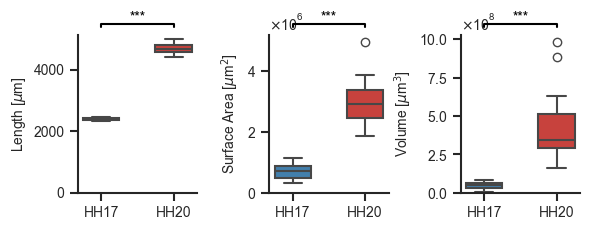

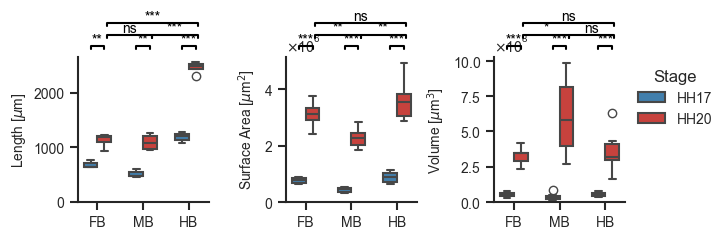

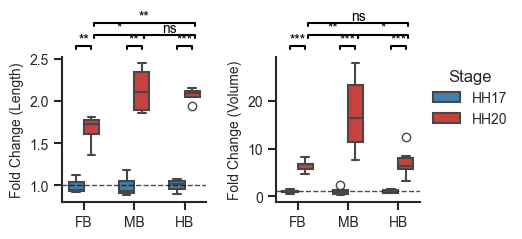

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

dpival = 100
FONT_SIZE = 10

plt.rcParams.update({
    'svg.fonttype': 'none',
    'font.size': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'xtick.labelsize': FONT_SIZE,
    'ytick.labelsize': FONT_SIZE,
    'legend.fontsize': FONT_SIZE,
    'axes.titlesize': FONT_SIZE,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

PALETTE = {'HH17': '#3182bd', 'HH20': '#de2d26'}
STAGES = ['HH17', 'HH20']
COMPARTMENTS = ['Forebrain', 'Midbrain', 'Hindbrain']

def set_common_style(ax, ylabel):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for side in ['left', 'bottom']:
        ax.spines[side].set_linewidth(1.5)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

def add_external_stat(ax, x1, x2, level, p_val):
    base_y = 1.05
    step = 0.08
    y = base_y + (level * step)
    ax.plot([x1, x1, x2, x2], [y, y+0.02, y+0.02, y],
            lw=1.5, color='black', clip_on=False,
            transform=ax.get_xaxis_transform())
    if p_val < 0.001: text = '***'
    elif p_val < 0.01: text = '**'
    elif p_val < 0.05: text = '*'
    else: text = 'ns'
    ax.text((x1+x2)*0.5, y+0.02, text, ha='center', va='bottom',
            color='black', transform=ax.get_xaxis_transform())

# Length Data
df_len = pd.read_csv('../data/csv/compartment_lengths.csv')
df_len['stage'] = df_len['stage'].astype(str).str.upper()

df_len['Hindbrain'] = df_len['mhb']
df_len['Midbrain'] = df_len['fmb'] - df_len['mhb']
df_len['Forebrain'] = df_len['end'] - df_len['fmb']
df_len['Total Length'] = df_len['end']

hh17_means_len = df_len[df_len['stage'] == 'HH17'][COMPARTMENTS + ['Total Length']].mean()
df_len_fc = df_len.copy()
for col in COMPARTMENTS + ['Total Length']:
    df_len_fc[col] = df_len[col] / hh17_means_len[col]

melted_len_raw = df_len.melt(id_vars=['stage'], value_vars=COMPARTMENTS, var_name='Compartment', value_name='Length')
melted_len_fc = df_len_fc.melt(id_vars=['stage'], value_vars=COMPARTMENTS, var_name='Compartment', value_name='Fold Change')

# Area & Volume Data
df_av = pd.read_csv("../data/csv/lumen_geometry.csv")
df_av['Stage'] = df_av['Stage'].astype(str).str.upper()

df_av_fc = df_av.copy()
for metric in ['Area', 'Volume']:
    for reg in COMPARTMENTS:
        hh17_mean = df_av[(df_av['Stage'] == 'HH17') & (df_av['Region'] == reg)][metric].mean()
        mask = df_av['Region'] == reg
        df_av_fc.loc[mask, metric] = df_av.loc[mask, metric] / hh17_mean

def plot_total(ax, data, x_col, y_col, ylabel, power=None, is_fc=False):
    stage_col = 'stage' if 'stage' in data.columns else 'Stage'
    sns.boxplot(data=data, x=stage_col, y=y_col, hue=stage_col, palette=PALETTE,
                width=0.5, linewidth=1.5, order=STAGES, legend=False, ax=ax)
    if is_fc:
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    else:
        ax.set_ylim(bottom=0)
    g1 = data[data[stage_col] == 'HH17'][y_col]
    g2 = data[data[stage_col] == 'HH20'][y_col]
    _, p = stats.ttest_ind(g1.dropna(), g2.dropna())
    add_external_stat(ax, 0, 1, 0, p)
    set_common_style(ax, ylabel)
    if not is_fc and power is not None:
        fmt = ticker.ScalarFormatter(useMathText=True)
        fmt.set_scientific(True)
        fmt.set_powerlimits((power, power))
        ax.yaxis.set_major_formatter(fmt)

def plot_compartments(ax, data, comp_col, y_col, ylabel, power=None, is_fc=False, show_legend=False):
    stage_col = 'stage' if 'stage' in data.columns else 'Stage'
    sns.boxplot(data=data, x=comp_col, y=y_col, hue=stage_col,
                order=COMPARTMENTS, palette=PALETTE, width=0.6, linewidth=1.5, ax=ax)
    if is_fc:
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    else:
        ax.set_ylim(bottom=0)
    for i, comp in enumerate(COMPARTMENTS):
        d1 = data[(data[comp_col] == comp) & (data[stage_col] == 'HH17')][y_col]
        d2 = data[(data[comp_col] == comp) & (data[stage_col] == 'HH20')][y_col]
        if not d1.empty and not d2.empty:
            _, p = stats.ttest_ind(d1.dropna(), d2.dropna())
            add_external_stat(ax, i - 0.15, i + 0.15, 0, p)
    inter_comps = [(0, 1, 1), (1, 2, 1), (0, 2, 2)]
    for (idx1, idx2, level) in inter_comps:
        comp1, comp2 = COMPARTMENTS[idx1], COMPARTMENTS[idx2]
        d1 = data[(data[comp_col] == comp1) & (data[stage_col] == 'HH20')][y_col]
        d2 = data[(data[comp_col] == comp2) & (data[stage_col] == 'HH20')][y_col]
        if not d1.empty and not d2.empty:
            _, p = stats.ttest_ind(d1.dropna(), d2.dropna())
            add_external_stat(ax, idx1 + 0.2, idx2 + 0.2, level, p)
    set_common_style(ax, ylabel)
    ax.set_xticks(range(len(COMPARTMENTS)))
    ax.set_xticklabels(['FB', 'MB', 'HB'])
    if not is_fc and power is not None:
        fmt = ticker.ScalarFormatter(useMathText=True)
        fmt.set_scientific(True)
        fmt.set_powerlimits((power, power))
        ax.yaxis.set_major_formatter(fmt)
    if show_legend:
        ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1, 1), title='Stage')
    else:
        ax.legend().remove()

# Figure 1: Absolute Values (Total)
fig1, axes1 = plt.subplots(1, 3, figsize=(6, 2.5), dpi=dpival)
plot_total(axes1[0], df_len, 'stage', 'Total Length', r'Length [$\mu$m]')
plot_total(axes1[1], df_av, 'Stage', 'Area', r'Surface Area [$\mu$m$^2$]', power=6)
plot_total(axes1[2], df_av, 'Stage', 'Volume', r'Volume [$\mu$m$^3$]', power=8)
fig1.tight_layout()
fig1.subplots_adjust(top=0.8)
fig1.savefig("fig1_total_absolute.svg", format='svg')

# Figure 2: Absolute Values (Compartment-wise)
fig2, axes2 = plt.subplots(1, 3, figsize=(7, 2.5), dpi=dpival)
plot_compartments(axes2[0], melted_len_raw, 'Compartment', 'Length', r'Length [$\mu$m]')
plot_compartments(axes2[1], df_av, 'Region', 'Area', r'Surface Area [$\mu$m$^2$]', power=6)
plot_compartments(axes2[2], df_av, 'Region', 'Volume', r'Volume [$\mu$m$^3$]', power=8, show_legend=True)
fig2.tight_layout()
fig2.subplots_adjust(top=0.75, right=0.9)
fig2.savefig("fig2_compartment_absolute.svg", format='svg')

# Figure 3: Fold Change (Compartment-wise Length & Volume)
fig3, axes3 = plt.subplots(1, 2, figsize=(5, 2.5), dpi=dpival)
plot_compartments(axes3[0], melted_len_fc, 'Compartment', 'Fold Change', 'Fold Change (Length)', is_fc=True)
plot_compartments(axes3[1], df_av_fc, 'Region', 'Volume', 'Fold Change (Volume)', is_fc=True, show_legend=True)
fig3.tight_layout()
fig3.subplots_adjust(top=0.75, right=0.85)
fig3.savefig("fig3_fold_change_length_volume.svg", format='svg')

plt.show()

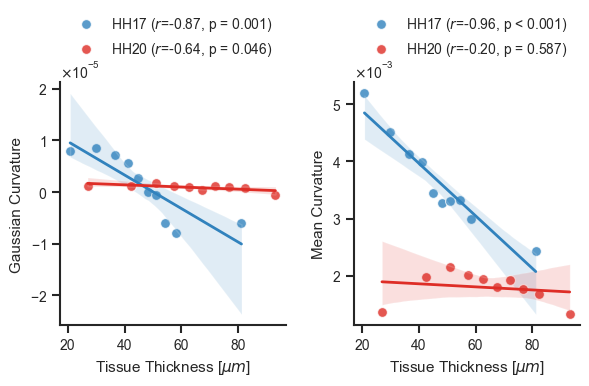

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.stats import pearsonr

dpival = 100
FONT_SIZE = 10

plt.rcParams.update({
    'svg.fonttype': 'none',
    'font.size': FONT_SIZE,
    'axes.labelsize': FONT_SIZE+1,
    'xtick.labelsize': FONT_SIZE,
    'ytick.labelsize': FONT_SIZE,
    'legend.fontsize': FONT_SIZE,
    'axes.titlesize': FONT_SIZE,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

PALETTE = {'HH17': '#3182bd', 'HH20': '#de2d26'}

master_csv = "../data/csv/spatchcocked_measurements.csv"
df = pd.read_csv(master_csv)

df['stage'] = df['stage'].astype(str).str.upper()

def plot_binned_correlation(ax, data, x_col, y_col, xlabel, ylabel, n_bins=10):
    """Calculates binned means, Pearson correlation, and plots to a specific axis."""
    if x_col not in data.columns or y_col not in data.columns:
        print(f"Skipping {y_col} vs {x_col}: columns missing from data.")
        return

    df_clean = data.dropna(subset=[x_col, y_col])
    binned_data = []

    for stage in ['HH17', 'HH20']:
        stage_df = df_clean[df_clean['stage'] == stage].copy()
        if len(stage_df) < n_bins:
            continue
        stage_df['x_bin'] = pd.qcut(stage_df[x_col], q=n_bins, duplicates='drop')
        bin_means = stage_df.groupby('x_bin', observed=False)[[x_col, y_col]].mean().reset_index()
        bin_means['stage'] = stage
        bin_means = bin_means.dropna()
        binned_data.append(bin_means)

    if not binned_data:
        return

    binned_df = pd.concat(binned_data, ignore_index=True)

    for stage in ['HH17', 'HH20']:
        stage_binned = binned_df[binned_df['stage'] == stage]
        if len(stage_binned) < 2:
            continue
        corr, pval = pearsonr(stage_binned[x_col], stage_binned[y_col])
        p_text = "p < 0.001" if pval < 0.001 else f"p = {pval:.3f}"
        legend_label = f"{stage} ($r$={corr:.2f}, {p_text})"
        sns.regplot(
            data=stage_binned, x=x_col, y=y_col, ax=ax,
            color=PALETTE[stage],
            scatter_kws={'s': 50, 'edgecolors': 'white', 'linewidths': 0.8},
            line_kws={'linewidth': 2},
            label=legend_label
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for side in ['left', 'bottom']:
        ax.spines[side].set_linewidth(1.5)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    fmt = ticker.ScalarFormatter(useMathText=True)
    fmt.set_scientific(True)
    fmt.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(fmt)

    ax.legend(frameon=False, loc='lower center', bbox_to_anchor=(0.5, 1.05), ncol=1)

fig, axes = plt.subplots(1, 2, figsize=(6, 4), dpi=dpival)

plot_binned_correlation(
    ax=axes[0], data=df,
    x_col='thickness', y_col='Gauss_Curvature',
    xlabel=r'Tissue Thickness [$\mu m$]',
    ylabel='Gaussian Curvature'
)

plot_binned_correlation(
    ax=axes[1], data=df,
    x_col='thickness', y_col='Mean_Curvature',
    xlabel=r'Tissue Thickness [$\mu m$]',
    ylabel='Mean Curvature'
)

plt.tight_layout()
plt.savefig("correlation_1x2_thickness_curvatures.svg", format='svg', bbox_inches='tight')
plt.show()

<ipython-input-13-f94710cc614e>:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap('plasma', 128)
<ipython-input-13-f94710cc614e>:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


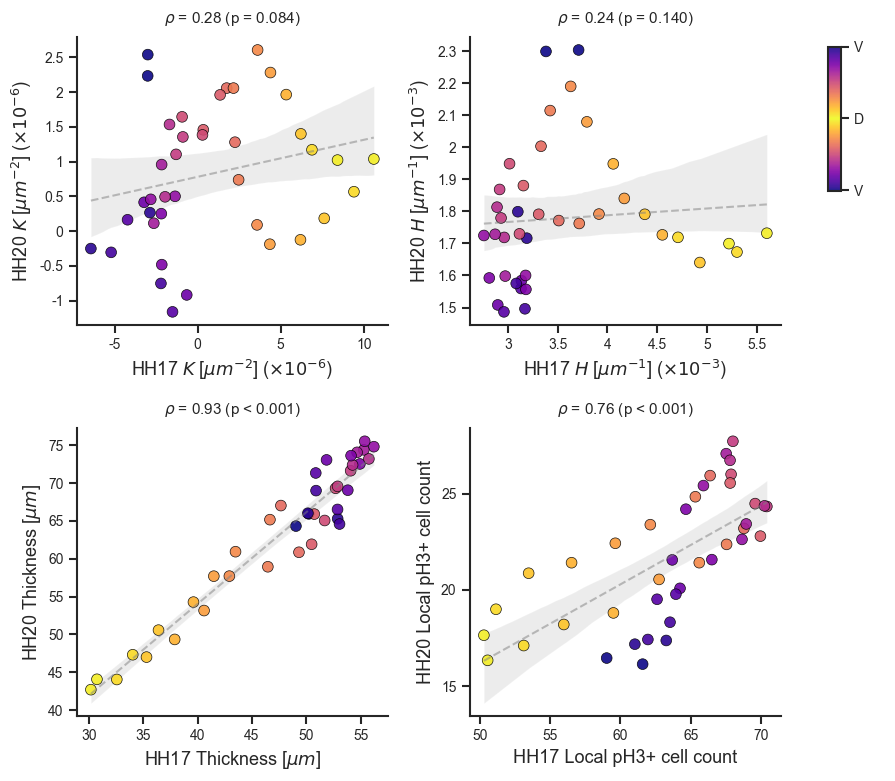

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import spearmanr

# Custom cyclic colormap: mirrors 'plasma' so ventral (±180°) is dark at both ends
# and dorsal (0°) is bright in the centre — matches the DV coordinate convention.
base_cmap = plt.cm.get_cmap('plasma', 128)
colors_half = base_cmap(np.linspace(0, 1, 128))
cyclic_colors = np.vstack((colors_half, colors_half[::-1]))
cyclic_plasma = mcolors.LinearSegmentedColormap.from_list('cyclic_plasma', cyclic_colors)

MASTER_CSV = "../data/csv/spatchcocked_measurements.csv"
N_ANGLE_BINS = 40

plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 13,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'svg.fonttype': 'none',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

PROPS = [
    ('Gauss_Curvature', r'$K$ [$\mu m^{-2}$]', -6, 0),
    ('Mean_Curvature',  r'$H$ [$\mu m^{-1}$]', -3, 1),
    ('thickness',       r'Thickness [$\mu m$]', 0, 2),
    ('phh3',            'Local pH3+ cell count', 0, 3)
]

df = pd.read_csv(MASTER_CSV)
df['stage'] = df['stage'].astype(str).str.upper()

fig, axes = plt.subplots(2, 2, figsize=(9, 8), dpi=100)
axes_flat = axes.flatten()

for col, base_label, exp, idx in PROPS:
    ax = axes_flat[idx]

    df_clean = df.dropna(subset=['angle_degrees', col])
    bins = np.linspace(-180, 180, N_ANGLE_BINS + 1)
    df_clean['angle_bin'] = pd.cut(df_clean['angle_degrees'], bins=bins)

    grouped = df_clean.groupby('angle_bin', observed=False).agg({
        col: lambda x: x[df_clean.loc[x.index, 'stage'] == 'HH17'].mean(),
        'angle_degrees': 'mean'
    }).rename(columns={col: 'HH17', 'angle_degrees': 'bin_center'})

    grouped['HH20'] = df_clean[df_clean['stage'] == 'HH20'].groupby('angle_bin', observed=False)[col].mean()
    comp_df = grouped.dropna(subset=['HH17', 'HH20'])

    corr, pval = spearmanr(comp_df['HH17'], comp_df['HH20'])
    p_text = "p < 0.001" if pval < 0.001 else f"p = {pval:.3f}"

    sns.regplot(
        data=comp_df, x='HH17', y='HH20', ax=ax,
        scatter=False, color='gray', line_kws={'linewidth': 1.5, 'linestyle': '--', 'alpha': 0.5}
    )

    scatter = ax.scatter(
        comp_df['HH17'], comp_df['HH20'],
        c=comp_df['bin_center'],
        cmap=cyclic_plasma,
        s=60, edgecolors='black', linewidths=0.5, alpha=0.9
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    label_suffix = f" ($\\times 10^{{{exp}}}$)" if exp != 0 else ""
    ax.set_xlabel(f"HH17 {base_label}{label_suffix}")
    ax.set_ylabel(f"HH20 {base_label}{label_suffix}")
    ax.set_title(f"$\\rho$ = {corr:.2f} ({p_text})", fontsize=11, pad=10)

    if exp != 0:
        func = ticker.FuncFormatter(lambda x, pos, e=exp: f'{x/(10**e):g}')
        ax.xaxis.set_major_formatter(func)
        ax.yaxis.set_major_formatter(func)

    if col == 'phh3':
        ax.set_yticks([15, 20, 25])

cbar_ax = fig.add_axes([0.93, 0.75, 0.015, 0.18])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(' ', rotation=270, labelpad=15)
cbar.set_ticks([-175, 0, 175])
cbar.set_ticklabels(['V', 'D', 'V'])

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig("Pattern_Correlation_Spearman.svg", format='svg', bbox_inches='tight')
plt.show()

 ## Supplementary — pHH3 spot density validation

 Independent validation of pHH3+ spot density comparing HH17 (66 hr incubation)
 and HH20 (90 hr incubation) tissue sections.  Data comes from raw Imaris spot
 detection (search radius R = 100 µm) on optical sections, prior to mesh
 projection.  This confirms that the difference in pHH3+ density seen in the
 spatchcocked data (Fig 6) reflects a genuine biological signal rather than an
 artefact of the projection method.

 The dataset is small (n ≈ 20 sections per stage) and is embedded inline — it
 does not require a separate CSV file.

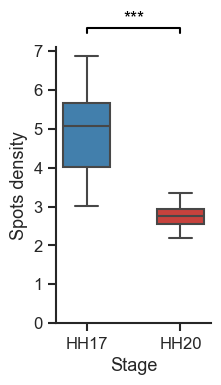

In [ ]:
import pandas as pd
import io
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

csv_data = """Filename,Total_Spots,Search_Radius_r,Mean_Density,Median_Density,Std_Density,Max_Density
66hr-FBMB-bottom1,81,100,4.02,3.0,2.77,16.0
66hr-FBMB-bottom10,125,100,5.65,6.0,2.81,14.0
66hr-FBMB-bottom11,71,100,3.69,4.0,1.98,9.0
66hr-FBMB-bottom12,129,100,5.49,6.0,2.91,13.0
66hr-FBMB-bottom13,82,100,4.02,4.0,2.25,10.0
66hr-FBMB-bottom2,87,100,3.57,3.0,2.38,11.0
66hr-FBMB-bottom3,74,100,5.58,6.0,2.43,11.0
66hr-FBMB-bottom4,60,100,5.27,5.0,2.72,12.0
66hr-FBMB-bottom8,126,100,4.34,4.0,2.38,11.0
66hr-FBMB-bottom9,64,100,5.08,5.0,3.08,12.0
66hr-FBMB-top2,69,100,4.56,4.0,2.75,12.0
66hr-FBMB-top3,71,100,3.01,3.0,1.6,10.0
66hr-FBMB-top4,81,100,4.87,5.0,2.66,14.0
66hr-FBMB-top5,121,100,5.22,5.0,2.86,13.0
66hr-FBMB-top6,128,100,6.86,7.0,3.85,16.0
66hr-FBMB-top7,103,100,3.26,3.0,2.02,11.0
66hr-FBMB-top8,65,100,4.6,4.0,2.38,12.0
66hr-HB-bottom1,72,100,6.69,7.0,2.79,14.0
66hr-HB-bottom2,45,100,9.56,10.0,4.08,20.0
66hr-HB-bottom4,55,100,5.81,6.0,2.72,12.0
66hr-HB-bottom6,81,100,6.84,7.0,3.64,18.0
FB-MB-90--Snap-1035,79,100,3.01,3.0,1.75,10.0
FB-MB-90-Snap-1030,75,100,2.83,3.0,1.53,8.0
FB-MB-90-Snap-1031,99,100,2.7,3.0,1.3,6.0
FB-MB-90-Snap-1032,78,100,2.93,3.0,1.28,6.0
FB-MB-90-Snap-1033,72,100,2.29,2.0,1.21,6.0
FB-MB-90-Snap-1034,59,100,2.76,3.0,1.33,6.0
FB-MB-90-Snap-1036,64,100,2.97,3.0,1.3,7.0
FB-MB-90-Snap-1038,73,100,2.64,3.0,1.31,7.0
FB-MB-90-Snap-1039,60,100,2.33,2.0,1.26,6.0
fb-mb-90-Snap-1054,66,100,3.34,3.0,1.42,7.0
fb-mb-90-Snap-1055,72,100,2.88,3.0,1.34,6.0
HB-90-Snap-1022,70,100,2.54,2.0,1.45,7.0
HB-90-Snap-1027,76,100,2.18,2.0,1.16,6.0
"""

df = pd.read_csv(io.StringIO(csv_data))

def get_stage(filename):
    filename_lower = filename.lower()
    if '66' in filename_lower: return 'HH17'
    elif '90' in filename_lower: return 'HH20'
    return 'Unknown'

df['Stage'] = df['Filename'].apply(get_stage)

dpival = 100
PALETTE = {'HH17': '#3182bd', 'HH20': '#de2d26'}
STAGES = ['HH17', 'HH20']

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

def set_common_style(ax, ylabel):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for side in ['left', 'bottom']:
        ax.spines[side].set_linewidth(1.5)
    ax.grid(False)
    ax.set_xlabel('Stage', fontsize=13, fontweight='normal')
    ax.set_ylabel(ylabel, fontsize=13, fontweight='normal')
    ax.tick_params(labelsize=12, width=1.5)

def add_external_stat(ax, x1, x2, level, p_val):
    base_y = 1.05
    step = 0.08
    y = base_y + (level * step)
    ax.plot([x1, x1, x2, x2], [y, y+0.02, y+0.02, y],
            lw=1.5, color='black', clip_on=False,
            transform=ax.get_xaxis_transform())
    if p_val < 0.001: text = '***'
    elif p_val < 0.01: text = '**'
    elif p_val < 0.05: text = '*'
    else: text = 'ns'
    ax.text((x1+x2)*0.5, y+0.02, text, ha='center', va='bottom',
            color='black', fontsize=13, fontweight='normal',
            transform=ax.get_xaxis_transform())

def plot_density(data, y_col, ylabel, filename, L=False):
    plt.figure(figsize=(2, 4), dpi=dpival)
    ax = sns.boxplot(data=data, x='Stage', y=y_col, hue='Stage', palette=PALETTE,
                     width=0.5, linewidth=1.5, order=STAGES, legend=False, showfliers=False)
    if L:
        ax.set_ylim(bottom=0)
    g1 = data[data['Stage'] == 'HH17'][y_col].dropna()
    g2 = data[data['Stage'] == 'HH20'][y_col].dropna()
    _, p = stats.ttest_ind(g1, g2, equal_var=False)
    add_external_stat(ax, 0, 1, 0, p)
    set_common_style(ax, ylabel)
    plt.subplots_adjust(top=0.8)
    plt.rcParams['svg.fonttype'] = 'none'
    plt.savefig(f"{filename}.svg", format='svg', bbox_inches='tight')

plot_density(
    data=df,
    y_col='Mean_Density',
    ylabel='Spots density',
    filename='HH17vsHH20_median_density_template',
    L=True
)

plt.show()